# 9주차_통계 기반 분석 방법론

- 공통요인분석(CFA)

---

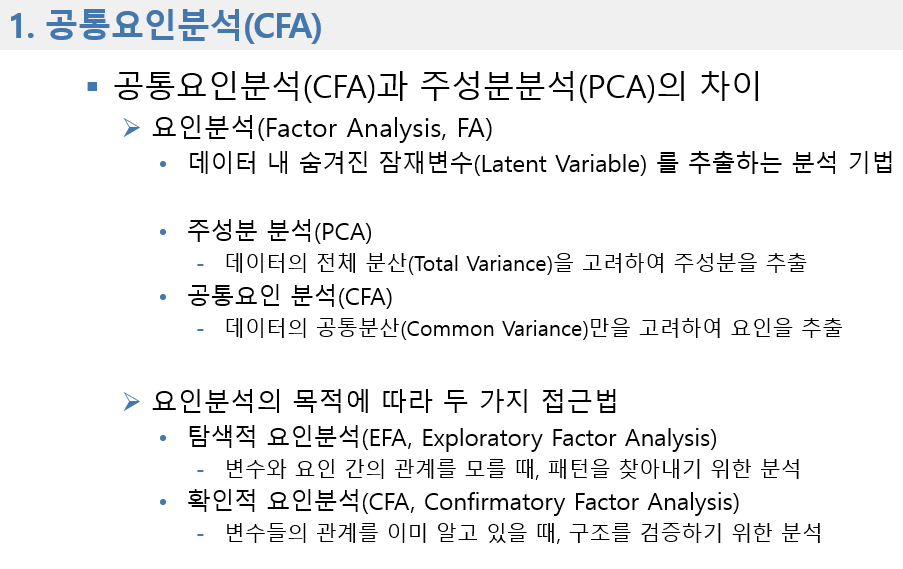

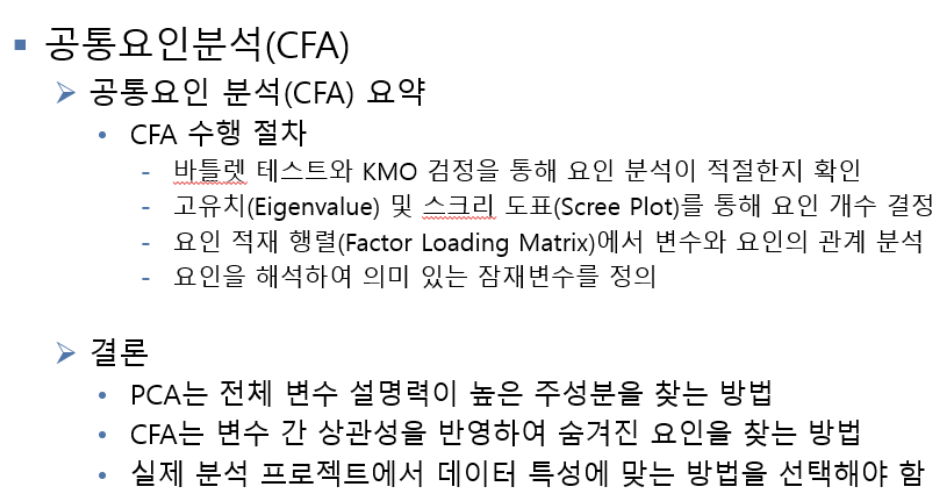

## 공통 요인 분석 개요 정리

### 🔹 1. 공통 요인 분석의 목적

- 많은 변수들이 사실은 몇 개의 **숨겨진 공통 요인(잠재 요인)**에 의해 설명될 수 있다는 전제 하에
    
    → 이 **잠재된 구조를 통계적으로 찾아내는 방법론**임
    
- 변수 간 상관관계의 이면에 존재하는 **공통된 영향 요인**을 발견하여
    
    → 데이터 구조를 간결하게 요약하고 해석 가능하게 만드는 데 목적이 있음
    

---

### 🔹 2. 데이터 전처리 단계

1. **비수치형 변수 제거**
    
    → 공통 요인 분석은 수치형 변수 간의 공분산 구조를 전제로 하므로 문자형, 범주형 변수는 제외 필요
    
2. **스케일 정규화 (MinMaxScaler)**
    
    → 변수들 간 단위 차이를 제거하고 공분산 구조의 왜곡을 방지하기 위함
    
    → 모든 변수 값을 0~1 범위로 선형 변환함
    

---

### 🔹 3. 요인 분석 적합성 검정

1. **바틀렛 구형성 검정**
    
    → 변수 간 상관관계가 유의한지 확인하기 위한 통계 검정
    
    → 귀무가설: 변수 간 상관관계가 없음
    
    → p-value < 0.05일 경우 요인 분석 적합함
    
2. **KMO 지수 (Kaiser-Meyer-Olkin)**
    
    → 변수들이 공통된 요인 구조를 잘 형성하고 있는지를 수치적으로 평가하는 지표
    
    → 0.6 이상일 경우 구조적 적합성이 있다고 판단함
    
    → 바틀렛은 "분석 가능한가?", KMO는 "구조가 괜찮은가?"를 보는 기준임
    

---

### 🔹 4. 요인 수 결정

1. **고유값(Eigenvalue) 계산**
    
    → 각 요인이 설명하는 분산의 양을 수치화한 값
    
    → 고유값이 1 이상이면 의미 있는 요인으로 간주 (Kaiser 기준)
    
2. **Scree Plot 시각화**
    
    → 고유값들을 점과 선으로 연결하여 감소 추세를 시각화
    
    → 고유값이 급격히 꺾이는 지점(elbow point) 이전까지의 요인을 선택함
    
    → 요약: 얼마나 많은 요인을 추출할 것인지 시각적으로 판단하는 단계임
    

---

### 🔹 5. 요인 분석 모델 학습 및 해석

1. **요인 분석 수행 (FactorAnalyzer)**
    
    → 선택된 요인 수(n_factors)를 바탕으로 요인 분석 모델 학습
    
    → 각 변수와 요인 간의 **요인 적재값(factor loading)** 추정
    
    → 요인 적재값은 ‘해당 변수가 특정 요인에 얼마나 강하게 관련되어 있는지’를 수치로 나타냄
    
2. **Varimax 회전 적용**
    
    → 각 변수의 적재값이 특정 요인에만 집중되도록 회전하여 해석력을 높이는 단계
    
    → 직교 회전(요인 간 독립 유지)을 통해 각 요인의 특성이 명확해짐
    

---

### 🔹 6. 요인 적재값 시각화 및 해석

1. **히트맵 시각화**
    
    → 변수와 요인 간의 적재값을 절대값 기준으로 색상으로 표현
    
    → 각 변수의 가장 강한 요인 연관성을 직관적으로 확인 가능
    
2. **요인 해석 및 명명**
    
    → 각 요인에 많이 적재된 변수들의 공통된 의미를 바탕으로
    
    해당 요인의 정성적 이름(예: 체력 요인, 득점 요인 등)을 부여함
    
    → 이는 분석 결과를 현장 또는 도메인 전문가의 언어로 번역하는 단계임
    

---

## 📌 최종 요약

공통 요인 분석은 단순히 변수 간 상관만 보는 것이 아니라

그 **상관의 뒤에 숨어 있는 구조적 원인**을 찾아내는 분석 방법임.

복잡한 수많은 지표를

→ 몇 개의 요인으로 축약하고,

→ 그 요인을 해석함으로써

→ 데이터에 대한 **심층적이고 요약된 통찰을 제공**함.

In [1]:
# ------------------------------------------------------------
# [전체 개요: Overview]
# 본 코드는 factor_analyzer 패키지를 활용하여 요인분석을 수행하기 전,  
# 데이터가 요인분석에 적합한지 평가하기 위해 바틀렛 구형성 검정과 KMO(Kaiser-Meyer-Olkin) 검정을 수행하는 예제임.  
# 바틀렛 검정은 변수 간 상관관계가 유의미한지를 확인하며,  
# KMO 검정은 변수들이 요인에 적절히 묶일 수 있을 정도로 상관되어 있는지를 평가함.

# ------------------------------------------------------------
# [처리 흐름: Step-by-step Flow]
# 1단계: 필요한 라이브러리 임포트
# 2단계: 샘플 데이터프레임 생성
# 3단계: 바틀렛 구형성 검정 수행
# 4단계: KMO 적합도 검정 수행
# ------------------------------------------------------------

from factor_analyzer import FactorAnalyzer
# 요인분석 수행을 위한 FactorAnalyzer 클래스 임포트

from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity, calculate_kmo
# 바틀렛 검정과 KMO 검정을 위한 함수들 개별 임포트

import pandas as pd
# 데이터프레임 생성을 위한 pandas 모듈 임포트

# ------------------------------------------------------------
# [2단계] 샘플 데이터 생성
# ------------------------------------------------------------

data = pd.DataFrame({
    "디자인": [5, 4, 3, 5, 4, 5, 3, 4, 3, 5],
    "성능": [4, 3, 5, 3, 4, 5, 2, 4, 5, 3],
    "사용편의성": [5, 3, 4, 5, 3, 4, 3, 5, 4, 5],
    "배터리": [4, 3, 3, 4, 5, 3, 4, 4, 5, 3],
    "가격": [3, 4, 5, 3, 4, 5, 4, 3, 4, 5],
})
# 5개 품질 속성 항목(디자인, 성능 등)에 대해 10명의 사용자 응답을 모의 생성하여 DataFrame 구성

# ------------------------------------------------------------
# [3단계] 바틀렛 구형성 검정
# ------------------------------------------------------------

bartlett_stat, bartlett_p = calculate_bartlett_sphericity(data)
# 변수 간 상관관계가 통계적으로 유의미한지를 평가하기 위한 바틀렛 검정을 수행하여,
# 검정 통계량(bartlett_stat)과 p-value(bartlett_p)를 반환

print(f"바틀렛 테스트 p-value: {bartlett_p}")
# 바틀렛 검정의 유의확률(p-value)을 출력하여 상관관계가 우연이 아님을 판단

# ------------------------------------------------------------
# [4단계] KMO 적합도 검정
# ------------------------------------------------------------

kmo_all, kmo_model = calculate_kmo(data)
# 전체 변수 쌍의 부분상관계수와 상관계수를 이용하여 KMO 값을 계산
# kmo_all은 각 변수별 KMO 값 벡터, kmo_model은 전체 모델의 KMO 지수

print(f"KMO 검정값: {kmo_model}")
# 전체 KMO 지수를 출력하여 요인분석 적합 여부 판단
# 일반적으로 0.6 이상이면 요인분석 수행 가능하다고 판단함


바틀렛 테스트 p-value: 0.5486991619483251
KMO 검정값: 0.37670850735057343


## 🔍 결과 해석

| 지표 | 값 | 기준 | 해석 |
| --- | --- | --- | --- |
| **바틀렛 검정 p-value** | 0.5487 | **0.05 이상** | 변수들 간 **상관관계가 유의하지 않음** → 요인분석 부적합 |
| **KMO 지수** | 0.3767 | **0.5 미만** | 변수들 간에 **공통 요인 구조 형성이 어려움** → 요인분석 부적합 |

## ❌ 결론

> 현재 데이터는 요인분석에 적합하지 않습니다.
> 

### 이유

- 바틀렛 검정 결과, 변수 간 상관관계가 **통계적으로 유의하지 않음** (p-value가 0.548 > 0.05).
- KMO 지수도 **0.5 미만**으로, 변수들이 **공통된 요인을 형성할 수 있을 정도로 연관되어 있지 않음**.

---

## ✅ 요인 분석 적합성 검정 요약 정리

### 🔍 바틀렛 구형성 검정 vs KMO 지수 비교 표

| 항목 | 설명 |
| --- | --- |
| **검정 이름** | 바틀렛 구형성 검정 (Bartlett’s Test of Sphericity) |
| **검정 목적** | 상관행렬이 단위행렬(대각선 1, 나머지 0)인지 검정함 |
| **귀무가설** | 변수들 간 상관관계가 없음 |
| **판단 기준** | p-value < 0.05 → 귀무가설 기각 |
| **해석** | p값이 작을수록 상관관계가 유의함 → 요인분석 적합함 |
| **필요성** | 요인분석은 변수 간 상관관계를 전제로 하므로, 상관이 없으면 분석이 무의미함 |

| 항목 | 설명 |
| --- | --- |
| **검정 이름** | KMO 지수 (Kaiser-Meyer-Olkin Measure) |
| **검정 목적** | 부분상관계수와 단순상관계수의 비율을 분석하여 변수들이 요인으로 묶일 수 있는지 평가함 |
| **지수 해석 기준** | 0.8 이상: 매우 우수0.7 이상: 적합0.6 이상: 보통0.5 이상: 한계0.5 미만: 부적합 |
| **해석** | 지수가 높을수록 변수 간에 공통 요인을 공유하고 있음 |
| **필요성** | KMO가 낮으면 변수 간 관련성이 약하여 요인으로 통합하는 것이 부적절함 |

## 🧪 실제 코드가 수행하는 역할

| 코드 | 수행 내용 및 역할 설명 |
| --- | --- |
| `bartlett_stat, bartlett_p = calculate_bartlett_sphericity(data)` | 변수 간 상관관계가 유의미한지 확인하기 위한 바틀렛 구형성 검정 수행 |
| `print(f"바틀렛 테스트 p-value: {bartlett_p}")` | p-value 출력 → 0.05 미만이면 요인분석에 적합하다고 판단함 |
| `kmo_all, kmo_model = calculate_kmo(data)` | 전체 변수들이 요인에 묶일 수 있을 정도로 상관되어 있는지를 확인하는 KMO 지수 계산 수행 |
| `print(f"KMO 검정값: {kmo_model}")` | 모델 전체 KMO 지수를 출력 → 0.6 이상일 경우 요인분석 가능성 존재 |

## 📌 최종 요약 정리

| 지표 | 역할 설명 | 판단 기준 | 요인분석 적합 여부 판단 기준 |
| --- | --- | --- | --- |
| 바틀렛 검정 | 변수 간 상관관계 존재 여부 확인 | p-value < 0.05 | 적합 |
| KMO 지수 | 변수 간 공통 요인 구조 적합성 판단 | 0.6 이상 | 적합 |

## 🧭 왜 두 검정이 필요한가?

- 바틀렛 검정은 **변수들이 서로 유의한 상관을 가지는지**를 확인하기 위한 수단임.
- KMO는 **상관이 공통요인에 기인한 것인지**를 판단하는 정량 지표임.
- 이 두 조건을 만족해야 **요인 분석의 타당성**과 **신뢰성**이 확보됨.

---

In [3]:
# 필요한 패키지 설치
# !pip install factor-analyzer  
# factor-analyzer 패키지가 설치되어 있지 않은 경우 사용자가 직접 pip 명령어를 통해 설치해야 함
# 이 패키지는 요인 분석(Factor Analysis) 및 관련 통계 검정을 위한 특화된 기능을 제공함

from sklearn.preprocessing import MinMaxScaler  
# 특성값을 0~1 범위로 선형 정규화하기 위한 MinMaxScaler 클래스를 불러오는 명령문
# 머신러닝 및 통계 분석 전 특성 간 단위 차이를 제거하고 분석의 수렴 속도와 안정성을 확보하기 위해 사용됨

from factor_analyzer import FactorAnalyzer  
# 주성분 분석(PCA)과 유사한 방식으로 데이터의 잠재 요인을 추출하는 요인 분석(Factor Analysis) 모델 클래스를 불러오는 명령문
# 공통 요인(Common Factor)을 기반으로 데이터의 구조를 단순화하여 해석 가능하게 만드는 분석 도구임

from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity  
# 요인 분석 적합성 검정을 위한 바틀렛 구형성 검정을 계산하는 함수 불러오기
# 상관행렬이 단위 행렬인지 여부를 통계적으로 검정하여 요인 분석이 유의미한지 판단하는 데 사용됨

from factor_analyzer.factor_analyzer import calculate_kmo  
# 변수 간 상관관계의 부분 상관과 단순 상관 비율을 기반으로 요인 분석 적합성을 판단하는 KMO 지수를 계산하는 함수 불러오기
# 변수들이 공통 요인을 설명할 수 있는 구조인지 여부를 평가하기 위해 사용됨

import pandas as pd  
# 테이블 형태의 데이터를 불러오고 조작하기 위한 pandas 라이브러리를 불러오는 명령문
# 데이터프레임(DataFrame)이라는 2차원 자료구조를 제공하며, 통계 분석과 시각화를 위한 기초 데이터를 구성함

import numpy as np  
# 수치 연산 및 다차원 배열 계산을 위한 NumPy 라이브러리를 불러오는 명령문
# 선형대수, 통계, 배열 조작 등 다양한 수치 해석 기능을 제공함

import seaborn as sns  
# 고수준의 통계적 시각화를 지원하는 seaborn 라이브러리를 불러오는 명령문
# 시각적으로 해석하기 쉬운 형태로 분포, 상관관계, 군집 등을 표현하는 데 사용됨

import matplotlib.pyplot as plt  
# 가장 기본적인 시각화 도구인 matplotlib의 pyplot 모듈을 불러오는 명령문
# 다양한 유형의 차트(선형 그래프, 산점도, 히스토그램 등)를 직접 그릴 수 있는 함수들을 제공함

plt.rcParams['figure.dpi'] = 300  
# 전체 그래프 출력의 DPI(Dots Per Inch)를 300으로 설정하여 고해상도의 시각화 이미지 생성을 유도함
# 인쇄 혹은 저장 시 이미지의 선명도를 높이고, 시각적 자료의 품질을 향상시키기 위해 설정함


In [6]:
# 데이터 불러오기
# https://www.kaggle.com/datasets/umutalpaydn/nba-20202021-season-player-stats
df = pd.read_csv("../../../main/datasets/nba2021_advanced.csv")

# 데이터 샘플 확인
df.head()

,Player,Pos,Age,Tm,G,MP,PER,TS%,3PAr,FTr,...,TOV%,USG%,OWS,DWS,WS,WS/48,OBPM,DBPM,BPM,VORP
0,Precious Achiuwa,PF,21,MIA,28,408,15.1,0.599,0.000,0.541,...,16.1,19.7,0.3,0.6,0.9,0.101,-2.8,-0.2,-3.0,-0.1
1,Jaylen Adams,PG,24,MIL,6,17,-6.9,0.125,0.250,0.000,...,0.0,19.7,-0.1,0.0,-0.1,-0.265,-15.6,-5.2,-20.9,-0.1
2,Steven Adams,C,27,NOP,27,760,15.9,0.592,0.006,0.397,...,20.1,12.8,1.2,0.5,1.7,0.109,-0.1,-1.0,-1.1,0.2
3,Bam Adebayo,C,23,MIA,26,873,22.7,0.641,0.015,0.469,...,16.2,24.6,2.3,1.3,3.6,0.196,2.9,2.0,4.9,1.5
4,LaMarcus Aldridge,C,35,SAS,18,480,15.2,0.542,0.298,0.093,...,6.4,22.3,0.2,0.5,0.7,0.075,0.3,-1.0,-0.7,0.2


In [7]:
# 변수 선택 및 데이터 스케일 정규화

# 요인 분석 할 칼럼만 선택 (문자형 변수 등 제거)
df1 = df.drop(['Player','Pos','Tm','Age'], axis='columns')  
# 전체 데이터프레임(df)에서 요인 분석에 사용하지 않을 변수들을 제거하여 새로운 데이터프레임(df1)을 생성함
# 'Player', 'Pos', 'Tm'은 문자열 기반의 범주형 변수로 수치 분석 대상이 아니며, 'Age'는 개별 선수의 나이 정보로 공통 요인을 반영하기 어려워 제외함
# axis='columns'는 열 기준으로 제거하겠다는 의미이며, 분석의 입력값으로 수치형 변수만 남기기 위한 전처리 단계임

# 데이터 정규화 적용
MinMaxScaler = MinMaxScaler()  
# 입력값을 0~1 범위로 선형 정규화하기 위한 MinMaxScaler 객체를 생성함
# 요인 분석이나 거리 기반 알고리즘에 앞서 변수 간 스케일 차이를 제거하고 분석 결과의 왜곡을 방지하기 위한 필수 전처리 작업임

df_minmax = MinMaxScaler.fit_transform(df1)  
# 정규화 대상 데이터프레임(df1)에 대해 fit_transform() 메서드를 적용하여 각 특성값을 0~1 범위로 정규화함
# fit()은 각 열의 최소값과 최대값을 계산하고, transform()은 해당 값들을 기준으로 스케일링을 수행함
# 결과는 numpy 배열 형태로 반환되며, 값은 모두 0 이상 1 이하의 실수로 변환됨

# 컬럼명 결합
df_minmax = pd.DataFrame(data=df_minmax, columns=df1.columns)  
# 정규화된 numpy 배열을 pandas의 DataFrame으로 변환함
# 원래 df1에 있던 열 이름을 그대로 지정하여 변수명 정보를 유지함으로써 이후 해석과 시각화의 가독성을 확보함
# 이 단계에서 df_minmax는 분석에 사용할 정규화된 수치형 데이터셋으로 완성됨

df_minmax.head()  
# 정규화된 데이터프레임의 상위 5개 행을 출력하여 변환이 제대로 이루어졌는지 확인함
# 값이 0~1 범위에 있는지, 데이터 구조가 의도한 대로 구성되었는지를 시각적으로 검토하기 위한 확인 단계임


,G,MP,PER,TS%,3PAr,FTr,ORB%,DRB%,TRB%,AST%,...,TOV%,USG%,OWS,DWS,WS,WS/48,OBPM,DBPM,BPM,VORP
0,0.931034,0.369427,0.703518,0.399333,0.000,0.202850,0.300000,0.365989,0.550000,0.143158,...,0.161,0.450382,0.245902,0.318182,0.239437,0.836054,0.688192,0.552147,0.677419,0.146341
1,0.172414,0.013649,0.427136,0.083333,0.250,0.000000,0.000000,0.336414,0.335714,0.282105,...,0.000,0.450382,0.180328,0.045455,0.098592,0.587075,0.452030,0.245399,0.402458,0.146341
2,0.896552,0.689718,0.713568,0.394667,0.006,0.148856,0.482857,0.332717,0.625000,0.212632,...,0.201,0.274809,0.393443,0.272727,0.352113,0.841497,0.738007,0.503067,0.706605,0.219512
3,0.862069,0.792539,0.798995,0.427333,0.015,0.175853,0.194286,0.428835,0.550000,0.587368,...,0.162,0.575064,0.573770,0.636364,0.619718,0.900680,0.793358,0.687117,0.798771,0.536585
4,0.586207,0.434941,0.704774,0.361333,0.298,0.034871,0.091429,0.258780,0.300000,0.240000,...,0.064,0.516539,0.229508,0.272727,0.211268,0.818367,0.745387,0.503067,0.712750,0.219512


In [8]:
# 바틀렛(Bartlett) 테스트
chi_square_value, p_value = calculate_bartlett_sphericity(df_minmax)  
# 요인 분석의 적합성을 판단하기 위한 바틀렛 구형성 검정을 수행함
# 입력 데이터(df_minmax)의 상관행렬이 단위행렬(대각선은 1, 나머지는 0)인지 여부를 통계적으로 검정함
# 귀무가설(H0): 모든 변수 간 상관관계가 존재하지 않음 → 요인 분석 부적합
# 대립가설(H1): 적어도 일부 변수 간 상관관계가 존재함 → 요인 분석 가능
# 반환값:
#   chi_square_value → 검정 통계량으로 사용되는 카이제곱 값
#       chi_square_value는 요인 분석이 가능한지 사전에 확인하기 위한 수치적 기준값임
#       p-value와 함께 해석해야 의미가 있음
#       → p-value < 0.05이면, chi_square_value가 충분히 크다고 보고 귀무가설을 기각, 요인 분석이 적절하다고 판단함
#   p_value → 검정 결과의 유의확률로, 이 값이 0.05 미만일 경우 귀무가설을 기각함

# 카이스퀘어, P-value 확인
chi_square_value, p_value  
# 바틀렛 검정 결과로 얻은 카이제곱 통계량과 p-value를 출력함
# p-value < 0.05일 경우, 변수들 간 상관관계가 통계적으로 유의하므로 요인 분석이 적합하다는 판단이 가능함


(20174.0826951171, 0.0)

In [9]:
# KMO 검정
kmo_all, kmo_test = calculate_kmo(df_minmax)  
# 변수들이 공통 요인(factor)을 통해 얼마나 잘 설명될 수 있는지를 평가하기 위한 KMO (Kaiser-Meyer-Olkin) 지수를 계산하는 명령문
# KMO 지수는 요인 분석이 '이론적으로 적합한지'를 판단하는 보조 지표로 사용되며,
# 각 변수 간 단순 상관계수와 부분 상관계수의 비율을 기반으로 계산됨
# 반환값:
#   - kmo_all: 변수별 KMO 값
#   - kmo_test: 전체 데이터 수준에서의 KMO 값
# 바틀렛 검정이 상관관계 유무(상관관계 없음 → 요인 분석 부적합)를 확인하는 필수 조건이라면,  
# KMO 지수는 변수들이 공통 요인 구조를 형성하는 데 적절한지(구조 적합성)를 평가하는 참고 기준임
# (변수들이 공통된 잠재 요인을 설명할 수 있을 정도로 구조화되어 있는지 확인)

kmo_test  
# 전체 변수 집합에 대한 단일 KMO 값을 출력하는 명령문
# 이 값은 요인 분석이 가능한지의 여부를 판단하는 **보조 지표**로 사용되며,  
# 변수들 간에 공통된 요인 구조가 존재하는지를 수치적으로 평가함
# 바틀렛 검정이 변수 간 상관관계의 유의성을 판단하는 **선결 조건**이라면,
# KMO 지수는 요인 분석의 **구조적 적합성 정도**를 판단하는 **보완 기준**임
# 해석 기준은 다음과 같음:
#   - 0.90 이상: 매우 우수함 (marvelous) → 요인 구조가 매우 명확함
#   - 0.80 ~ 0.89: 우수함 (meritorious) → 요인 구조가 잘 형성되어 있음
#   - 0.70 ~ 0.79: 보통임 (middling) → 요인 분석이 가능하나 약간의 구조적 한계 존재
#   - 0.60 ~ 0.69: 부족함 (mediocre) → 요인 분석 가능하나 구조 안정성이 낮음
#   - 0.50 ~ 0.59: 열악함 (miserable) → 요인 분석 신뢰도 낮음, 주의 요망
#   - 0.50 미만: 부적합 (unacceptable) → 공통 요인 구조가 부족하여 요인 분석 비권장



/Users/khb43/anaconda3/envs/HUFS_AI_Study/lib/python3.10/site-packages/factor_analyzer/utils.py:244: UserWarning: The inverse of the variance-covariance matrix was calculated using the Moore-Penrose generalized matrix inversion, due to its determinant being at or very close to zero.
  warnings.warn(


0.7017388419159665

In [10]:
# 전체 요인적재값 확인

fa = FactorAnalyzer(n_factors=30, rotation=None)  
# 요인 분석을 위한 FactorAnalyzer 객체를 생성함
# n_factors=30은 요인을 최대 30개까지 추출해보겠다는 의미로, 이는 현재 데이터의 변수 개수에 해당함
# rotation=None은 요인 회전을 하지 않겠다는 설정임
# 회전을 적용하지 않으면 각 변수들이 여러 요인에 걸쳐 분산될 수 있으므로 해석이 복잡해질 수 있음

# ✅ 여기서 말하는 '요인(Factor)'이란?
# → 변수들에 공통적으로 영향을 미치는 **숨겨진 원인** 혹은 **잠재적인 성분(latent variable)**을 의미함
    # 예: 선수의 경기 능력을 수치화한 여러 변수들(득점, 리바운드, 어시스트 등)이 
    # 사실은 몇 가지 '스타일' 또는 '역할군(예: 수비형, 공격형)'으로 요약될 수 있음
# → 이 '스타일'이나 '역할군'이 바로 요인(Factor)이며, 데이터로는 직접 관측되지 않고 통계적으로 추정되는 숨겨진 구조임

fa.fit(df_minmax)  
# 정규화된 수치형 데이터(df_minmax)를 사용해 요인 분석 모델을 학습하는 과정임
# 요인 분석은 '관측된 변수들'이 사실은 더 적은 수의 '공통된 요인'들에 의해 결정된다는 가정 하에 이루어짐    
    # 이 전제가 실제 데이터에 적합한지 사전에 검토하는 과정이 바로 바틀렛 검정과 KMO 검정
        # 바틀렛 구형성 검정: 변수들 간 상관관계가 통계적으로 유의미한가? → 요인 분석 적용 가능한지 판단
            # 요인 분석을 "시작할 수 있는가?" → 선결 조건
        # KMO 적합도 지수: 변수들이 공통 요인으로 설명될 만큼 구조화되어 있는가? → 요인 분석이 구조적으로 타당한가 판단
            # 요인 분석이 "얼마나 잘 맞을 것 같은가?" → 적합성 평가
# 예를 들어 30개의 서로 다른 통계 지표가 실제로는 3~5개의 숨겨진 요인(공격력, 수비력, 활동성 등)으로 설명된다고 보는 것임

# 이 과정에서는 공분산 행렬을 기반으로 요인 부하량(factor loadings)과 고유값(eigenvalues)을 추정함
# → 요인 부하량은 각 변수가 해당 요인에 얼마나 강하게 관련되어 있는지를 나타내는 계수값이며,
# → 고유값은 해당 요인이 데이터의 전체 분산 중 얼마를 설명하는지를 나타냄

ev, v = fa.get_eigenvalues()  
# ev는 요인별 고유값 리스트, v는 각 변수와 관련된 다른 부가 정보
    # → v는 모델 내부 처리용으로 쓰이는 보조 행렬 정보이며, 사용자 입장에서 의미 해석 필요 없음 → "사용하지 않음"으로 처리해도 무방
# 학습된 요인 분석 모델에서 고유값(eigenvalues)을 추출함
# 고유값은 각 요인이 전체 데이터의 분산(정보량)을 얼마나 설명하는지를 나타냄
# 고유값이 클수록 해당 요인이 중요한 정보를 더 많이 설명하고 있다는 뜻임
# 일반적으로 고유값이 1 이상인 요인만을 의미 있는 요인으로 간주하며, 이는 'Kaiser 기준'이라 불림
# v는 요인과 직접 관련 없는 추가 정보이며 여기서는 사용하지 않음
#
# ✅ 요인은 어떻게 생겼는가?
# → 요인 자체는 '숫자 한 개'가 아니라, 각 변수에 대한 영향력을 나타내는 **벡터(1차원 배열)**임
# → 예를 들어 "요인 1"은 변수 A, B, C 각각에 대해 [0.82, -0.14, 0.67] 같은 '부하값'을 갖게 되며,
#    이는 요인 1이 변수 A에 강하게, B에는 약하게, C에는 중간 정도 영향을 준다는 의미임
# → 이러한 요인 벡터가 n_factors 개수만큼 계산되며, 변수 x 요인 형태의 **요인 적재 행렬(factor loading matrix)**을 구성함

np.round_(ev, 2)  
# 계산된 고유값 배열(ev)을 소수점 둘째 자리까지 반올림하여 보기 쉽게 출력함
# 각 고유값은 해당 요인이 전체 데이터의 분산을 얼마나 설명하는지를 수치적으로 요약한 지표임
# 이후 이 고유값을 시각화하여 요인의 개수를 결정하기 위한 Scree Plot을 그리는 데 사용됨

# actorAnalyzer(n_factors=30)로 30개의 요인을 요청했음에도 
# get_eigenvalues()에서 22개만 반환된 이유는 다음과 같은 통계적 제약과 factor_analyzer 라이브러리의 동작 방식 때문
# ev의 길이가 30이 아닌 이유는, get_eigenvalues()가 반환하는 고유값 배열은 
# 데이터에 실제로 존재할 수 있는 최대 고유값 수, 즉 "입력 변수 수(열 수)"만큼만 생성되기 때문
# n_factors=3: "최대 30개 요인을 모델 내부에서 고려하겠다"는 설정 (모델 학습용)
# get_eigenvalues() 결과가 22개인 이유: 실제 가능한 고유값 개수는 **입력 변수 수(22개)**와 동일하기 때문
# 데이터 변수 수가 30개보다 작다면?: 고유값은 그 수만큼만 반환됨. 요인을 30개 지정해도 의미 없음


/Users/khb43/anaconda3/envs/HUFS_AI_Study/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


array([7.91, 3.53, 2.25, 1.59, 1.45, 1.05, 0.86, 0.67, 0.59, 0.57, 0.45,
       0.37, 0.24, 0.17, 0.11, 0.08, 0.07, 0.03, 0.01, 0.  , 0.  , 0.  ])

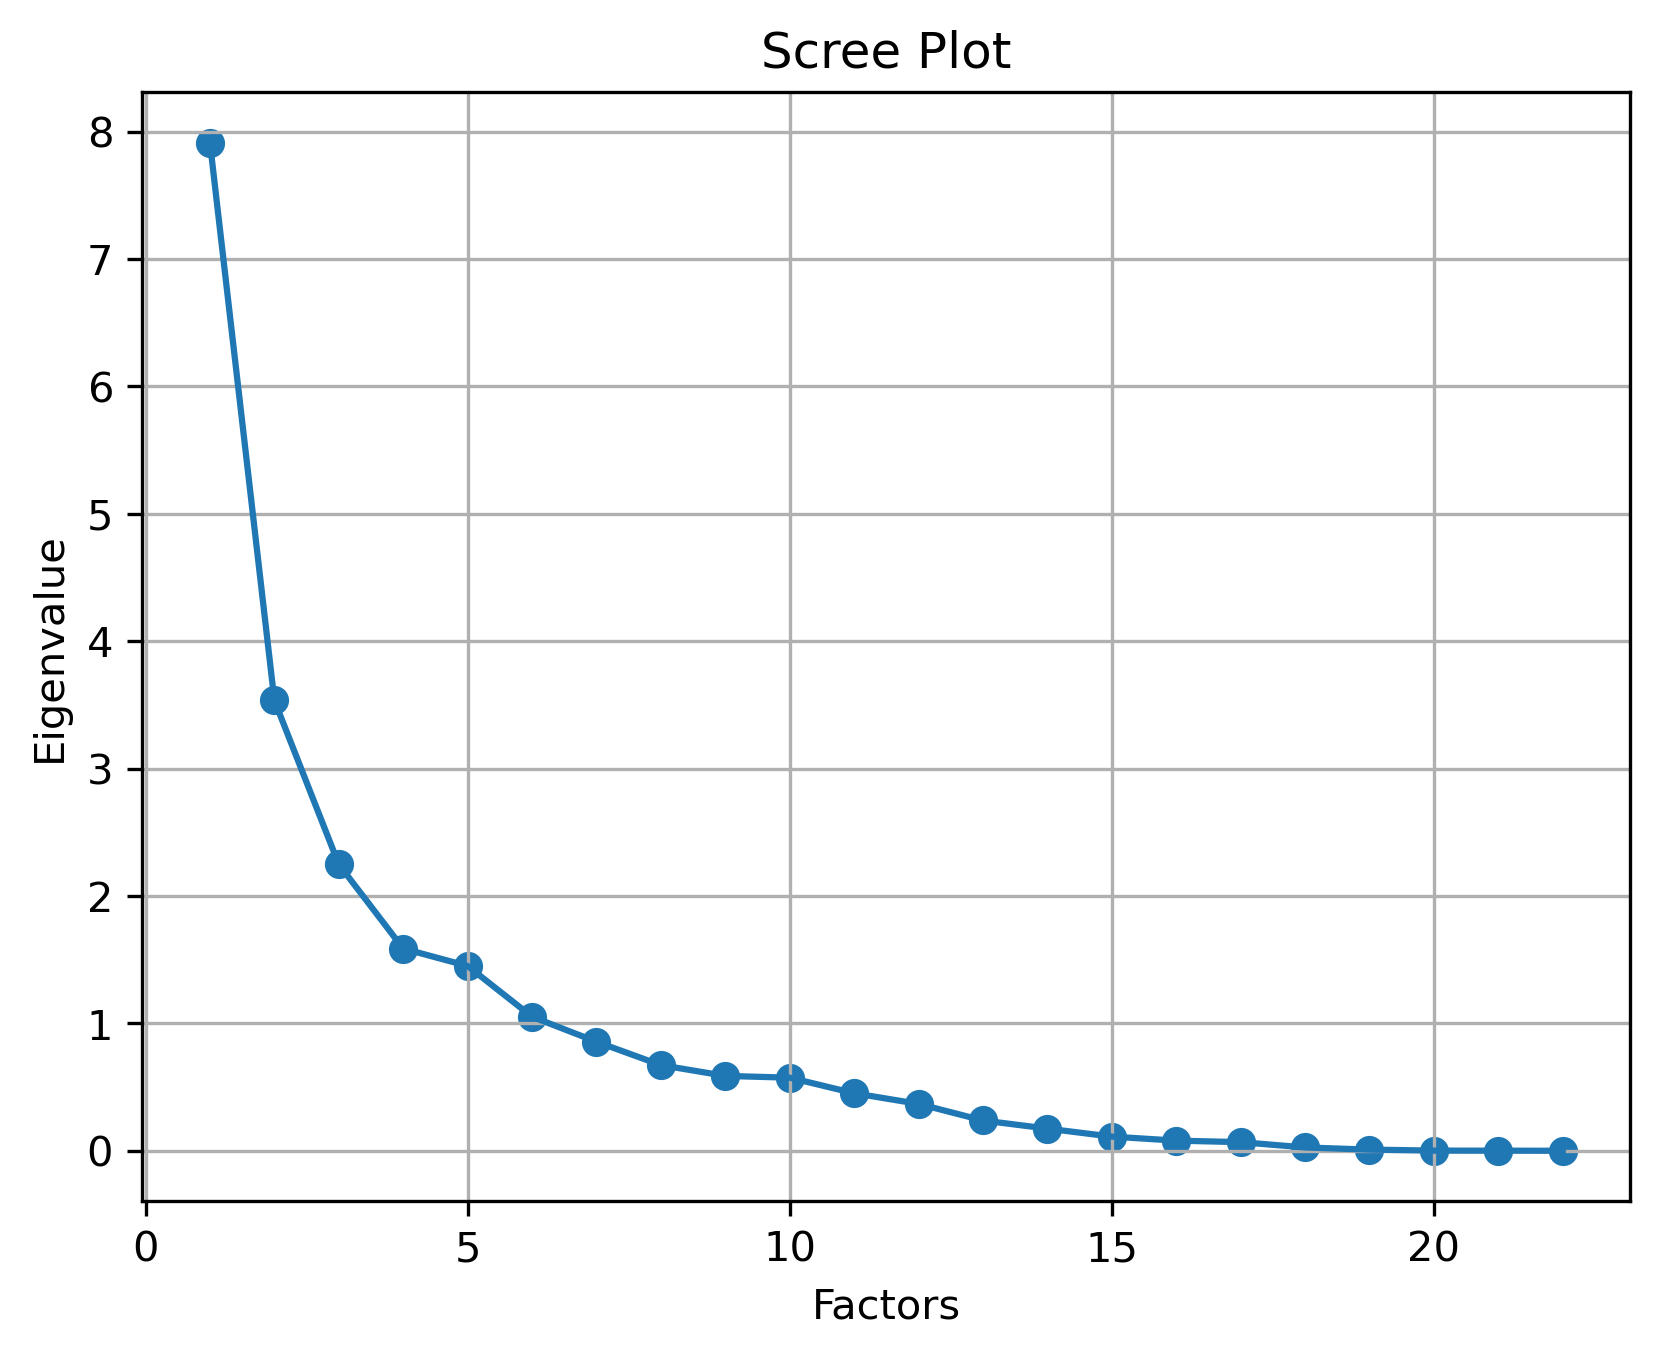

In [11]:
# 스크리 도표 시각화

plt.scatter(range(1, df_minmax.shape[1]+1), ev)  
# 고유값(eigenvalue)을 산점도 형태로 시각화하는 명령문
# x축에는 요인 번호(1부터 시작), y축에는 각 요인의 고유값(ev)을 대응시켜 점으로 표시함
# 요인 번호는 데이터의 변수 개수(df_minmax.shape[1])와 동일하게 설정함
# 이 시각화는 요인 수 결정 시, 고유값의 '급격한 하락점(elbow)'을 시각적으로 찾기 위한 선행 단계임

plt.plot(range(1, df_minmax.shape[1]+1), ev)  
# 위의 산점도에 고유값을 선 그래프로 연결하여 추세를 시각화하는 명령문
# 고유값의 하락 패턴을 더 명확히 볼 수 있도록 도와주며, elbow point를 판단하는 데 도움을 줌
# elbow point란 고유값의 감소 속도가 급격히 꺾이는 지점을 말하며, 이 지점 이전까지의 요인 수가 유의미하다고 판단함
# 이를 통해 'elbow point' — 즉, 고유값이 급격히 떨어지는 지점 — 을 찾을 수 있음
# 이 지점은 ‘이 이후의 요인은 정보가 적으므로 버려도 된다’는 통계적 기준이 됨

plt.title('Scree Plot')  
# 그래프 상단에 'Scree Plot'이라는 제목을 부여하는 명령문
# 분석자가 그래프의 의미를 명확히 이해할 수 있도록 시각적 설명을 제공함

plt.xlabel('Factors')  
# x축의 레이블을 'Factors'(요인 번호)로 설정함
# 각 점과 선이 어떤 요인을 나타내는지를 설명하는 역할을 수행함

plt.ylabel('Eigenvalue')  
# y축의 레이블을 'Eigenvalue'(고유값)로 설정함
# 각 요인이 데이터의 분산을 얼마나 설명하는지를 나타내는 수치를 시각적으로 표현함

plt.grid()  
# 그래프에 격자선을 추가하여 각 점의 위치를 더 쉽게 해석할 수 있도록 도와주는 명령문
# 고유값과 요인 번호 간의 관계를 수치적으로 파악할 때 시각적 기준선을 제공함

plt.show()  
# 작성된 시각화 결과를 출력하여 사용자에게 보여주는 명령문
# 이 시점에서 matplotlib은 모든 설정을 반영하여 완성된 Scree Plot을 화면에 렌더링함


### 용어 정리

| 용어 | 의미 |
| --- | --- |
| **요인(Factor)** | 여러 변수에 공통적으로 영향을 미치는 숨겨진 잠재적 원인 (ex: 공격력, 수비력) |
| **요인 수 선정** | 의미 있는 정보만 요약하고 불필요한 노이즈는 버리기 위한 과정 (Scree Plot로 판단) |
| **Varimax 회전** | 변수-요인 간 관계를 더 뚜렷하게 만들기 위한 수학적 변환 |
| **요인 적재값(loading)** | 특정 변수가 특정 요인과 얼마나 관련 있는지를 나타내는 숫자 (보통 -1 ~ 1 사이) |

In [13]:
# 요인 수 선정 및 요인-변수 간 요인적재값 확인

fa = FactorAnalyzer(n_factors=4, rotation="varimax")  
# 요인 분석 모델을 생성하며, 추출할 요인의 수를 4개로 지정함
# n_factors=4는 Scree Plot 등을 통해 의미 있다고 판단된 요인의 개수를 반영한 설정임
# rotation="varimax"는 요인 회전 방식을 지정하는 인자임
# Varimax 회전은 요인 간 독립성을 유지하면서 각 요인의 해석을 쉽게 만들어 주는 직교 회전 방식임
# 이 회전을 통해 각 변수는 한 요인에만 강하게 적재되고, 나머지에는 약하게 적재되도록 구조를 단순화함
# 이를 통해 변수별 요인 분류가 명확해지고, 해석력이 향상됨

fa.fit(df_minmax)  
# 정규화된 데이터(df_minmax)에 대해 요인 분석 모델을 학습시키는 명령문
# 변수 간의 공분산 구조를 분석하여 잠재 요인들과의 관계를 추정함
# 회전까지 포함된 형태로 요인 부하량(factor loading)을 계산함
# 요인 부하량은 각 변수와 요인 간의 관련 정도를 수치로 표현한 값임
# 예: 특정 변수가 요인 1에는 0.85, 요인 2에는 0.10이라면 → 변수는 요인 1에 주로 관련된 것으로 해석함

factor_loadings = pd.DataFrame(fa.loadings_, index=df_minmax.columns)  
# 학습된 요인 분석 모델에서 요인 적재값(loading matrix)을 가져와 데이터프레임 형태로 변환함
# fa.loadings_는 각 변수와 각 요인 간의 관련 강도를 나타내는 2차원 배열(변수 수 × 요인 수)임
# 각 행은 하나의 변수, 각 열은 하나의 요인을 의미함
# 예: [0.72, 0.04, -0.11, 0.01] → 이 변수는 요인 1과 강하게 연관됨
# index=df_minmax.columns를 지정하여, 각 행이 어떤 변수에 해당하는지 이름을 부여함

factor_loadings  
# 요인 적재값 테이블을 출력함
# 이 표를 통해 어떤 변수가 어떤 요인에 가장 강하게 적재되었는지를 확인 가능함
# 절대값이 0.4 이상이면 실질적 관련성이 있는 것으로 해석하며,  
# 각 변수는 가장 높은 적재값을 가지는 요인에 속한다고 간주함


/Users/khb43/anaconda3/envs/HUFS_AI_Study/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


,0,1,2,3
G,0.280363,-0.120974,0.823695,0.054468
MP,0.235239,-0.114616,0.820694,0.349032
PER,0.832268,0.305573,0.147761,0.411650
TS%,0.746473,0.103235,0.151836,0.069871
3PAr,-0.015289,-0.593922,0.004644,-0.180311
FTr,0.087057,0.356382,-0.173463,0.112161
ORB%,0.042655,0.785599,-0.047214,-0.058840
DRB%,0.105775,0.711622,0.131665,-0.009666
TRB%,0.076869,0.971609,0.092116,-0.049174
AST%,0.072484,-0.176681,0.082553,0.571263


<AxesSubplot:>

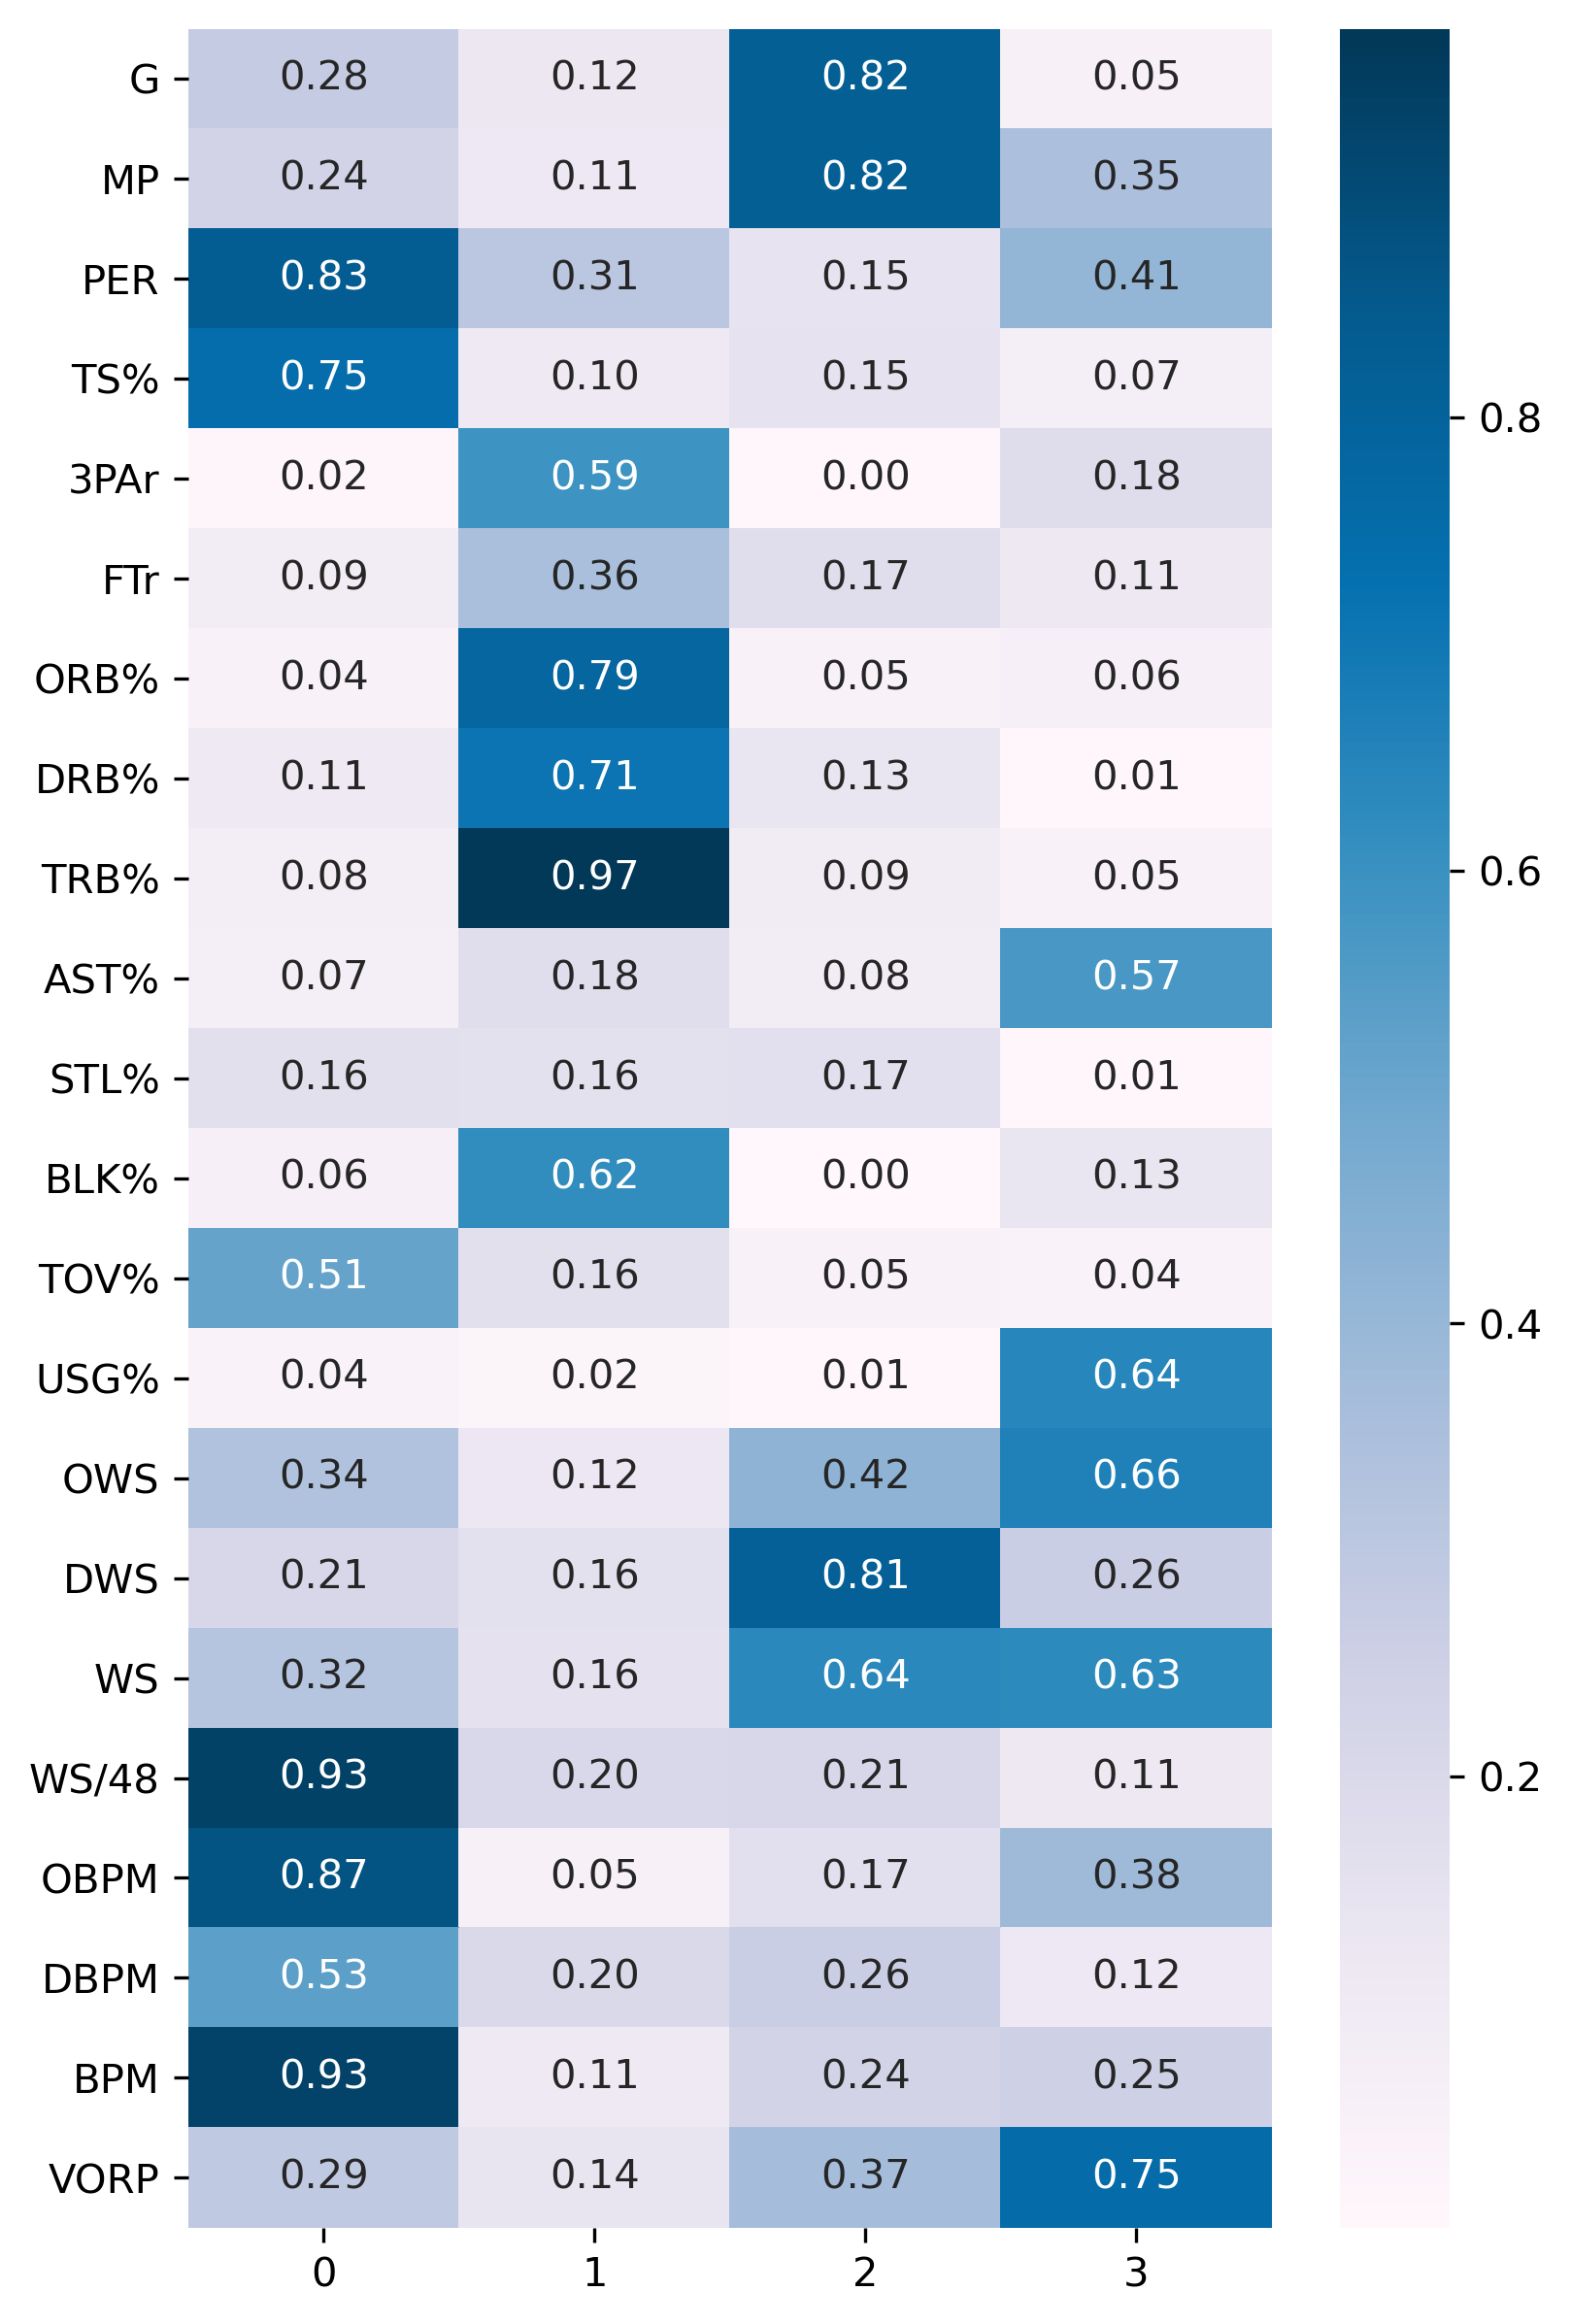

In [ ]:
# 변수 간 요인적재값 시각화

plt.figure(figsize=(6, 10))  
# 시각화될 그래프의 전체 크기를 설정하는 명령문
# figsize=(6, 10)은 너비가 6인치, 높이가 10인치인 세로형 시각화 화면을 생성함
# 변수 수가 많아 행이 긴 경우, 세로 공간을 충분히 확보하여 가독성을 높이기 위함

sns.heatmap(abs(factor_loadings), cmap="PuBu", annot=True, fmt='.2f')  
# seaborn의 heatmap() 함수를 사용하여 요인 적재값(factor loadings)을 시각화함
# abs(factor_loadings)는 모든 적재값의 절대값을 사용하여 부호(±)가 아닌 강도의 크기만 표현함
# → 이는 변수와 요인 간 관련성의 크기만 보려는 의도로, 부호는 방향일 뿐 관련성의 세기를 판단하려면 절대값을 봐야 함
# cmap="PuBu"는 색상 팔레트를 보라-파랑 계열로 설정함 (색이 짙을수록 적재값이 큼)
# annot=True는 각 셀 내부에 수치를 함께 표시함
# fmt='.2f'는 소수점 둘째 자리까지 반올림하여 수치를 깔끔하게 출력함

# 절대값으로 봐야함  

# 요인 적재값은 부호(양수/음수)가 아니라 절대값의 크기를 기준으로 해석함
# 값의 부호는 요인의 방향성을 의미하지만, 실질적인 관련 강도는 절대값이 크냐 작으냐에 달려 있음
# 예: -0.75나 +0.75는 모두 해당 변수와 요인이 강하게 연관되어 있음을 뜻함
